<a href="https://colab.research.google.com/github/Thujaina/ECG-classification----Res-Net/blob/main/categorical_CE_resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from keras.layers import (
    Conv1D, MaxPooling1D, Dense, BatchNormalization,
    GlobalAveragePooling1D, Dropout, Add, Input
)

from keras.models import Model

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

from google.colab import drive

In [3]:
drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Mounted at /content/drive
Train shape: (87554, 188)
Test shape: (21892, 188)


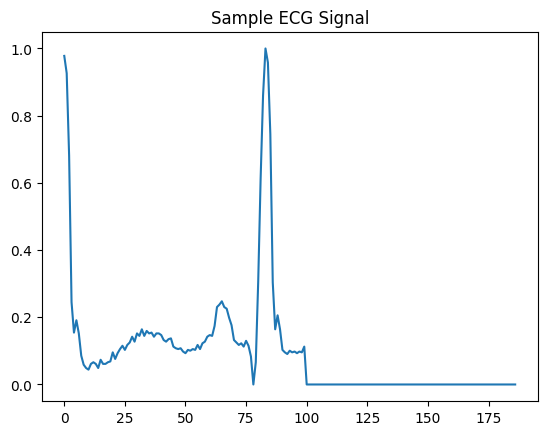

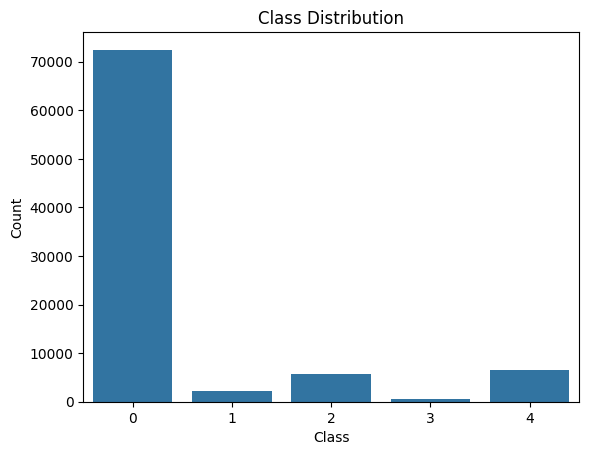

Train Missing: 0
Test Missing : 0


In [4]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()

sns.barplot(x=[0,1,2,3,4], y=counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

print("Train Missing:", train.isna().sum().sum())
print("Test Missing :", test.isna().sum().sum())

In [5]:
from sklearn.preprocessing import StandardScaler

X_train = train.iloc[:, :-1].values.astype(np.float32)
y_train = train.iloc[:, -1].values

X_test = test.iloc[:, :-1].values.astype(np.float32)
y_test = test.iloc[:, -1].values

# Scale while data is still 2D
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Now reshape for CNN
X_test = X_test.reshape(-1, 187, 1)

y_test_cat = to_categorical(y_test, 5)

In [6]:
def resnet_block(x, filters, stride=1):

    shortcut = x

    x = Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)

    return x

In [7]:
def resnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(32, 3, activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x, 64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x, 128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x, 256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(5, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [8]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_train[train_idx], X_train[val_idx]
    y_tr, y_va = y_train[train_idx], y_train[val_idx]

    smote = SMOTE(random_state=42)

    X_tr, y_tr = smote.fit_resample(X_tr, y_tr)

    # reshape for CNN
    X_tr = X_tr.reshape(-1, 187, 1)
    X_va = X_va.reshape(-1, 187, 1)

    y_tr = to_categorical(y_tr, 5)
    y_va = to_categorical(y_va, 5)

    model = resnet_ecg()

    model.fit(
        X_tr, y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

    cv_accuracies.append(acc)

print("\nMean CV:", np.mean(cv_accuracies))
print("Std CV :", np.std(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 58s 11ms/step - accuracy: 0.9364 - loss: 0.1865
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9764 - loss: 0.0720
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9855 - loss: 0.0444
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9893 - loss: 0.0332
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9922 - loss: 0.0256
Fold 1 Accuracy: 0.9717

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 53s 11ms/step - accuracy: 0.9372 - loss: 0.1828
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9751 - loss: 0.0745
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9843 - loss: 0.0480
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9884 - loss: 0.0351
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9907 - loss: 0.0280
Fold 2 Accuracy: 0.9348

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 52s 1

In [9]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

smote = SMOTE(random_state=42)

X_train_final, y_train_final = smote.fit_resample(
    X_train_final, y_train_final
)

X_train_final = X_train_final.reshape(-1, 187, 1)
X_val_final   = X_val_final.reshape(-1, 187, 1)

y_train_final = to_categorical(y_train_final, 5)
y_val_final   = to_categorical(y_val_final, 5)

In [10]:
model = resnet_ecg()

#early_stop = EarlyStopping(
 #   monitor='val_loss',
  #  patience=3,
   # restore_best_weights=True
#)

history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=10,
    batch_size=64,
    #callbacks=[early_stop]
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 64s 11ms/step - accuracy: 0.9408 - loss: 0.1734 - val_accuracy: 0.9643 - val_loss: 0.1288
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9777 - loss: 0.0669 - val_accuracy: 0.9703 - val_loss: 0.1126
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9860 - loss: 0.0429 - val_accuracy: 0.9758 - val_loss: 0.1024
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9900 - loss: 0.0311 - val_accuracy: 0.9774 - val_loss: 0.1016
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9922 - loss: 0.0245 - val_accuracy: 0.9390 - val_loss: 0.2137
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - accuracy: 0.9937 - loss: 0.0197 - val_accuracy: 0.9643 - val_loss: 0.1337
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9949 - loss: 0.0162 - val_accuracy: 0.9745 - val_loss: 0.1189
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9955 - loss: 

In [11]:
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)
y_val_true = np.argmax(y_val_final, axis=1)

print("Validation MCC:", matthews_corrcoef(y_val_true, y_val_pred))

548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
Validation MCC: 0.9433287123857728


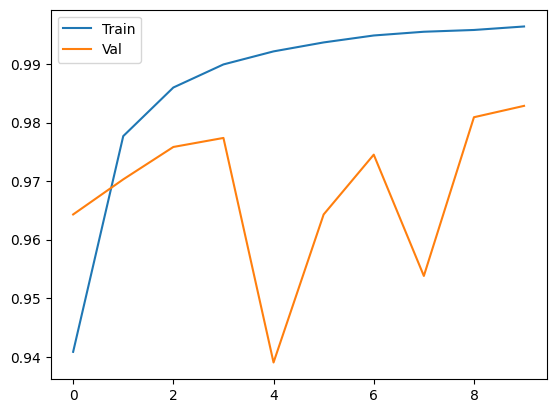

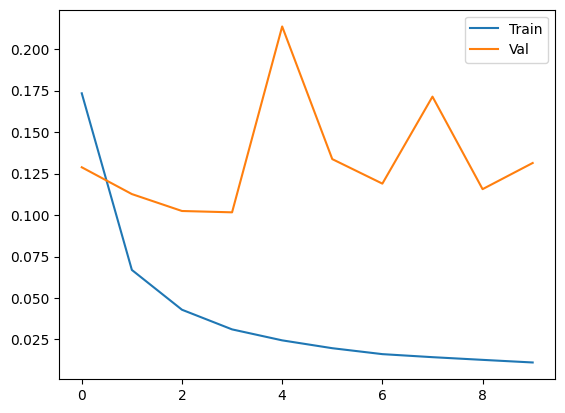

In [12]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend()
plt.show()

Test Accuracy: 0.9815000891685486
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     18118
         1.0       0.88      0.71      0.79       556
         2.0       0.93      0.97      0.95      1448
         3.0       0.82      0.80      0.81       162
         4.0       0.99      0.98      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.92      0.89      0.90     21892
weighted avg       0.98      0.98      0.98     21892



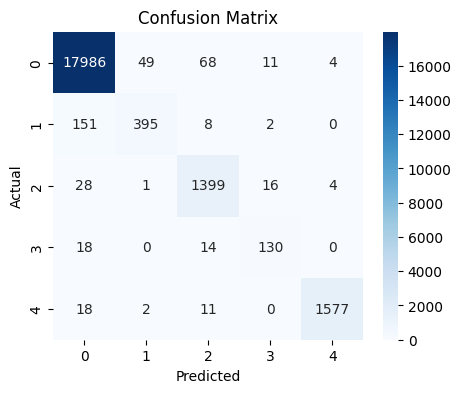

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
# Training metrics (last epoch)

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

# Test metrics

test_loss, test_acc = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")

print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")

print(f"Testing Accuracy    : {test_acc:.4f}")
print(f"Testing Loss        : {test_loss:.4f}")

Training Accuracy   : 0.9964
Validation Accuracy : 0.9829
Training Loss       : 0.0111
Validation Loss     : 0.1314
Testing Accuracy    : 0.9815
Testing Loss        : 0.1511
